In [1]:
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import tqdm
import yt
yt.set_log_level("error")

## Allow files to be readable by `yt`

In [2]:
# yt refuses to read files that are cylindrical in 1D geometry
# therefore, we remove the corresponding flag here
run_directory = '../run'
for filename in os.listdir(run_directory):
    if filename.startswith('plt'):
        header_file = os.path.join(run_directory, filename, 'Header')
        # Read file
        with open(header_file) as f:
            text = f.read()
        # Replace the flag that indicates cylindrical geometry
        text = re.sub('(0\.\d+) \n1\n0', '\g<1> \n0\n0', text)
        # Write file
        with open(header_file, 'w') as f:
            f.write(text)        

#  Extract data

In [3]:
def extract_data( iteration, quantity, level ):
    ds = yt.load('../run/plt%05d/' %iteration, hint="castro")
    ad = ds.covering_grid( level=level, 
                           left_edge=ds.domain_left_edge, 
                           dims=[ds.domain_dimensions[0]*2**level, 1, 1] )
    q = ad[quantity].to_ndarray().squeeze()
    r = np.linspace(
        ds.domain_left_edge[0],
        ds.domain_right_edge[0],
        ds.domain_dimensions[0]*2**level)
    return r, q, ds.current_time

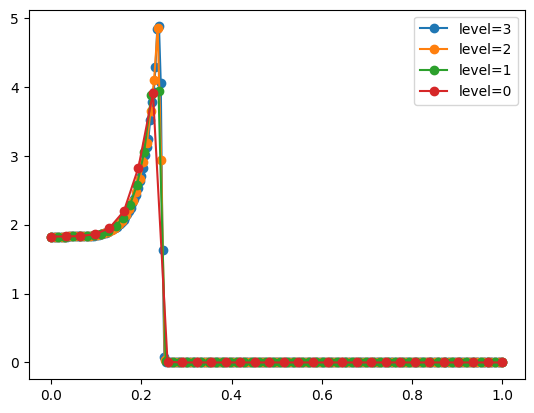

In [4]:
# plot data at difference resolutions
plt.clf()
for level in range(3,-1,-1):
    r, q, t = extract_data( 100, 'pressure', level)
    plt.plot(r, q, '-o', label='level=%d'%level)
plt.legend(loc=0)

In [6]:
# Extract data from different time 
# Note that time is not regularly spaced
t_arr = []
q_arr = []
rmax_arr = []
iterations = sorted([ int(filename[3:]) 
                     for filename in os.listdir(run_directory) 
                     if filename.startswith('plt') ])
for iteration in tqdm.tqdm(iterations):
    r, q, t = extract_data(iteration, 'density', level=2)
    rmax = r[np.argmax(q)]
    t_arr.append(t)
    rmax_arr.append(rmax)
    q_arr.append(q)
q_arr = np.stack(q_arr)
t_arr = np.array(t_arr)
r_arr = r.to_ndarray()

# Interpolate on a grid with regularly-spaced time
interp = RegularGridInterpolator(points=(t_arr, r_arr), values=q_arr, bounds_error=False, fill_value=None)
t_interp, r_interp = np.meshgrid(
    np.linspace(0, t_arr.max(), 1000), 
    np.linspace(0, r_arr.max(), 1000), indexing='ij')
q_interp = interp((t_interp, r_interp))

100%|███████████████████████████████████████████| 76/76 [00:06<00:00, 11.05it/s]


In [7]:
# Calculate analytical solution
gamma = 1.4
rho = 1. # g / cm^3
E = 1. # erg / cm
r_analytical = np.sqrt( gamma+1 ) * (E/np.pi/rho)**(1./4) * np.sqrt(t_arr)

Text(0.5, 0, 't (s)')

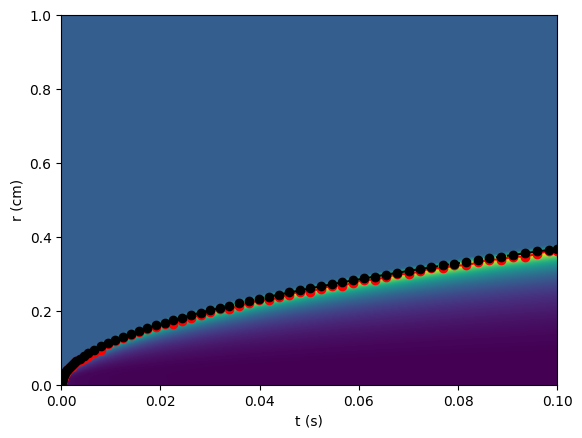

In [8]:
plt.imshow(q_interp.T, origin='lower', extent=[0, t_arr.max(), 0, r_arr.max()], aspect='auto')
plt.plot(t_arr, rmax_arr, 'r-o')
plt.plot(t_arr, r_analytical, 'k--o')
plt.ylabel('r (cm)')
plt.xlabel('t (s)')